Dean Hickman

Spring 2025

CS 343: Neural Networks

In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

plt.show()
plt.style.use(['seaborn-v0_8-colorblind', 'seaborn-v0_8-darkgrid'])
plt.rcParams.update({'font.size': 16})

np.set_printoptions(suppress=True, precision=3)

# Automatically reload external modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## TensorFlow install test

*Sanity check that TensorFlow is installed correctly:*

Executing the following cell should print 3 

In [13]:
tf.print(tf.reduce_sum([tf.constant(1), tf.constant(2)]))

3


# Project 4 | Transfer Learning

## Task 1: Implement ConvNet4AccelV2 in TensorFlow

Construct the familiar `ConvNet4AccelV2` neural network architecture from last project in TensorFlow's high level `Keras::Sequential` API. Also like your last project, train on the STL-10 training set and test on the STL-10 test set.

### 1a. Use the high level `Keras::Sequential` API in TensorFlow to implement the architecture of ConvNet4AccelV2 from the last project. Train and test your network on the STL-10 dataset. 

**Goal:** Achieve ≥ 47% on either the validation set or test set. *For our purposes, getting ≥ 47% validation accuracy at any point during training is enough (i.e. doesn't need to be at the very end of training).*

#### Notes

- You should use the usual STL-10 data acquisition and preprocessing code from your last project. You can use the default split, or modify it yourself.
- You don't need to do a hyperparameter search. Values that worked on the CNN project should get you in the ballpark here. The goal is to show that you know how to put together a `keras::Sequential` model and have it work successfully.
- You may have to tweak the hyperparameters by hand a little (number of epochs, regularization, number of hidden units, etc.) to hit your accuracy target, but it should not take too much effort.
- TensorFlow needs the RGB color channel AFTER the spatial dimensions. For example: (32, 32, 3), not (3, 32, 32). You may therefore need to slightly modify the preprocesssing pipeline for this project.

#### Keras Sequential workflow

Recall the `Keras::Sequential` common workflow:

- Build structure of network with `Keras::Sequential`.
- Compile network with your choice of optimizer, loss, and metrics.
- Fit the model (remembering to pass in the appropriate training and validation sets). This results a history object that can be used to examine training/validation accuracy and loss.
- Evaluate the model on the test set. This returns test loss and accuracy.

#### Helpful documentation

These documentation pages should be helpful:
- https://www.tensorflow.org/api_docs/python/tf/keras/Sequential
- https://www.tensorflow.org/api_docs/python/tf/keras/Model#compile
- https://www.tensorflow.org/api_docs/python/tf/keras/Model#evaluate
- https://www.tensorflow.org/api_docs/python/tf/keras/Model#fit
- https://www.tensorflow.org/api_docs/python/tf/keras/Model#summary

In [14]:
import load_stl10_dataset
from preprocess_data import load_stl10

In [19]:
classes = np.loadtxt(os.path.join('data', 'stl10_binary', 'class_names.txt'), dtype=str)

load_stl10_dataset.purge_cached_dataset()

X_train, y_train, X_test, y_test, X_val, y_val, X_dev, y_dev = load_stl10(scale_fact=3)

Images are: (5000, 96, 96, 3)
Labels are: (5000,)
Resizing 5000 images to 32x32...Done!
Saving Numpy arrays the images and labels to ./numpy...Done!


In [20]:
tf.random.set_seed(0)
tf.keras.backend.clear_session()

def ConvNet4AccelV2(input_shape=(32, 32, 3), n_kers=16, ker_sz=7, dense_interior_units=100, pooling_sizes=3, pooling_strides=2, n_classes=10, reg=0.0, dropout_rate=0.0):
    model = tf.keras.models.Sequential()
    model.add(tf.keras.layers.Conv2D(n_kers, ker_sz, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(reg), input_shape=input_shape))
    model.add(tf.keras.layers.MaxPooling2D(pooling_sizes, pooling_strides))
    model.add(tf.keras.layers.Flatten())
    model.add(tf.keras.layers.Dense(dense_interior_units, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(reg)))
    model.add(tf.keras.layers.Dropout(dropout_rate))
    model.add(tf.keras.layers.Dense(n_classes, activation='softmax', kernel_regularizer=tf.keras.regularizers.l2(reg)))
    return model

model = ConvNet4AccelV2(reg = 0.01, dropout_rate = 0.1)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

xTrain= tf.transpose(X_train, [0, 2, 3, 1])
xValid = tf.transpose(X_val, [0, 2, 3, 1])
yTrain = tf.one_hot(y_train, 10)
yValid = tf.one_hot(y_val, 10)


history = model.fit(xTrain, yTrain, epochs=10, validation_data=(xValid, yValid))

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.2142 - loss: 3.8922 - val_accuracy: 0.3660 - val_loss: 2.4441
Epoch 2/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.3492 - loss: 2.4174 - val_accuracy: 0.4360 - val_loss: 1.9828
Epoch 3/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.4114 - loss: 2.0308 - val_accuracy: 0.4820 - val_loss: 1.7830
Epoch 4/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4560 - loss: 1.8374 - val_accuracy: 0.4680 - val_loss: 1.7474
Epoch 5/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4623 - loss: 1.7371 - val_accuracy: 0.4840 - val_loss: 1.7224
Epoch 6/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4962 - loss: 1.6478 - val_accuracy: 0.4940 - val_loss: 1.6671
Epoch 7/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5195 - loss: 1.5968 - val_accuracy: 0.4920 - val_loss: 1.6818
Epoch 8/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5300 - loss: 1.5735 - val_accu

### 1b. Make 2 "high quality" plots showing the following

- Training and validation accuracy (y axis) over training epochs (x axis).
- Training and validation loss (y axis) over epochs (x axis).

A high quality plot consists of:
- A useful title
- X and Y axis labels
- A legend

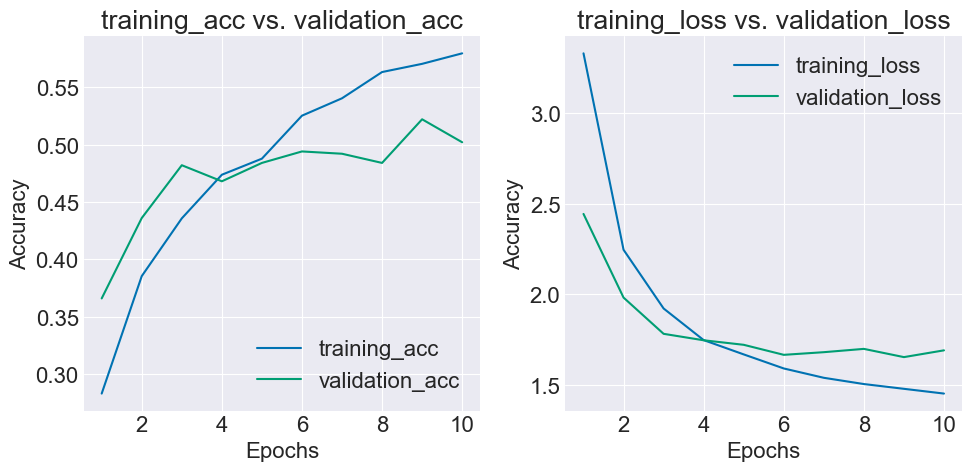

In [34]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epoch = range(1, len(acc)+ 1)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(epoch, acc, label='training_acc')
plt.plot(epoch, val_acc, label='validation_acc')
plt.title('training_acc vs. validation_acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epoch, loss, label='training_loss')
plt.plot(epoch, val_loss, label='validation_loss')
plt.title('training_loss vs. validation_loss')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

### 1c. Visualize predictions

Make a 5x5 grid of the first 25 images in the test dataset. Label each with the predicted class label string (English label, not an int code).

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step


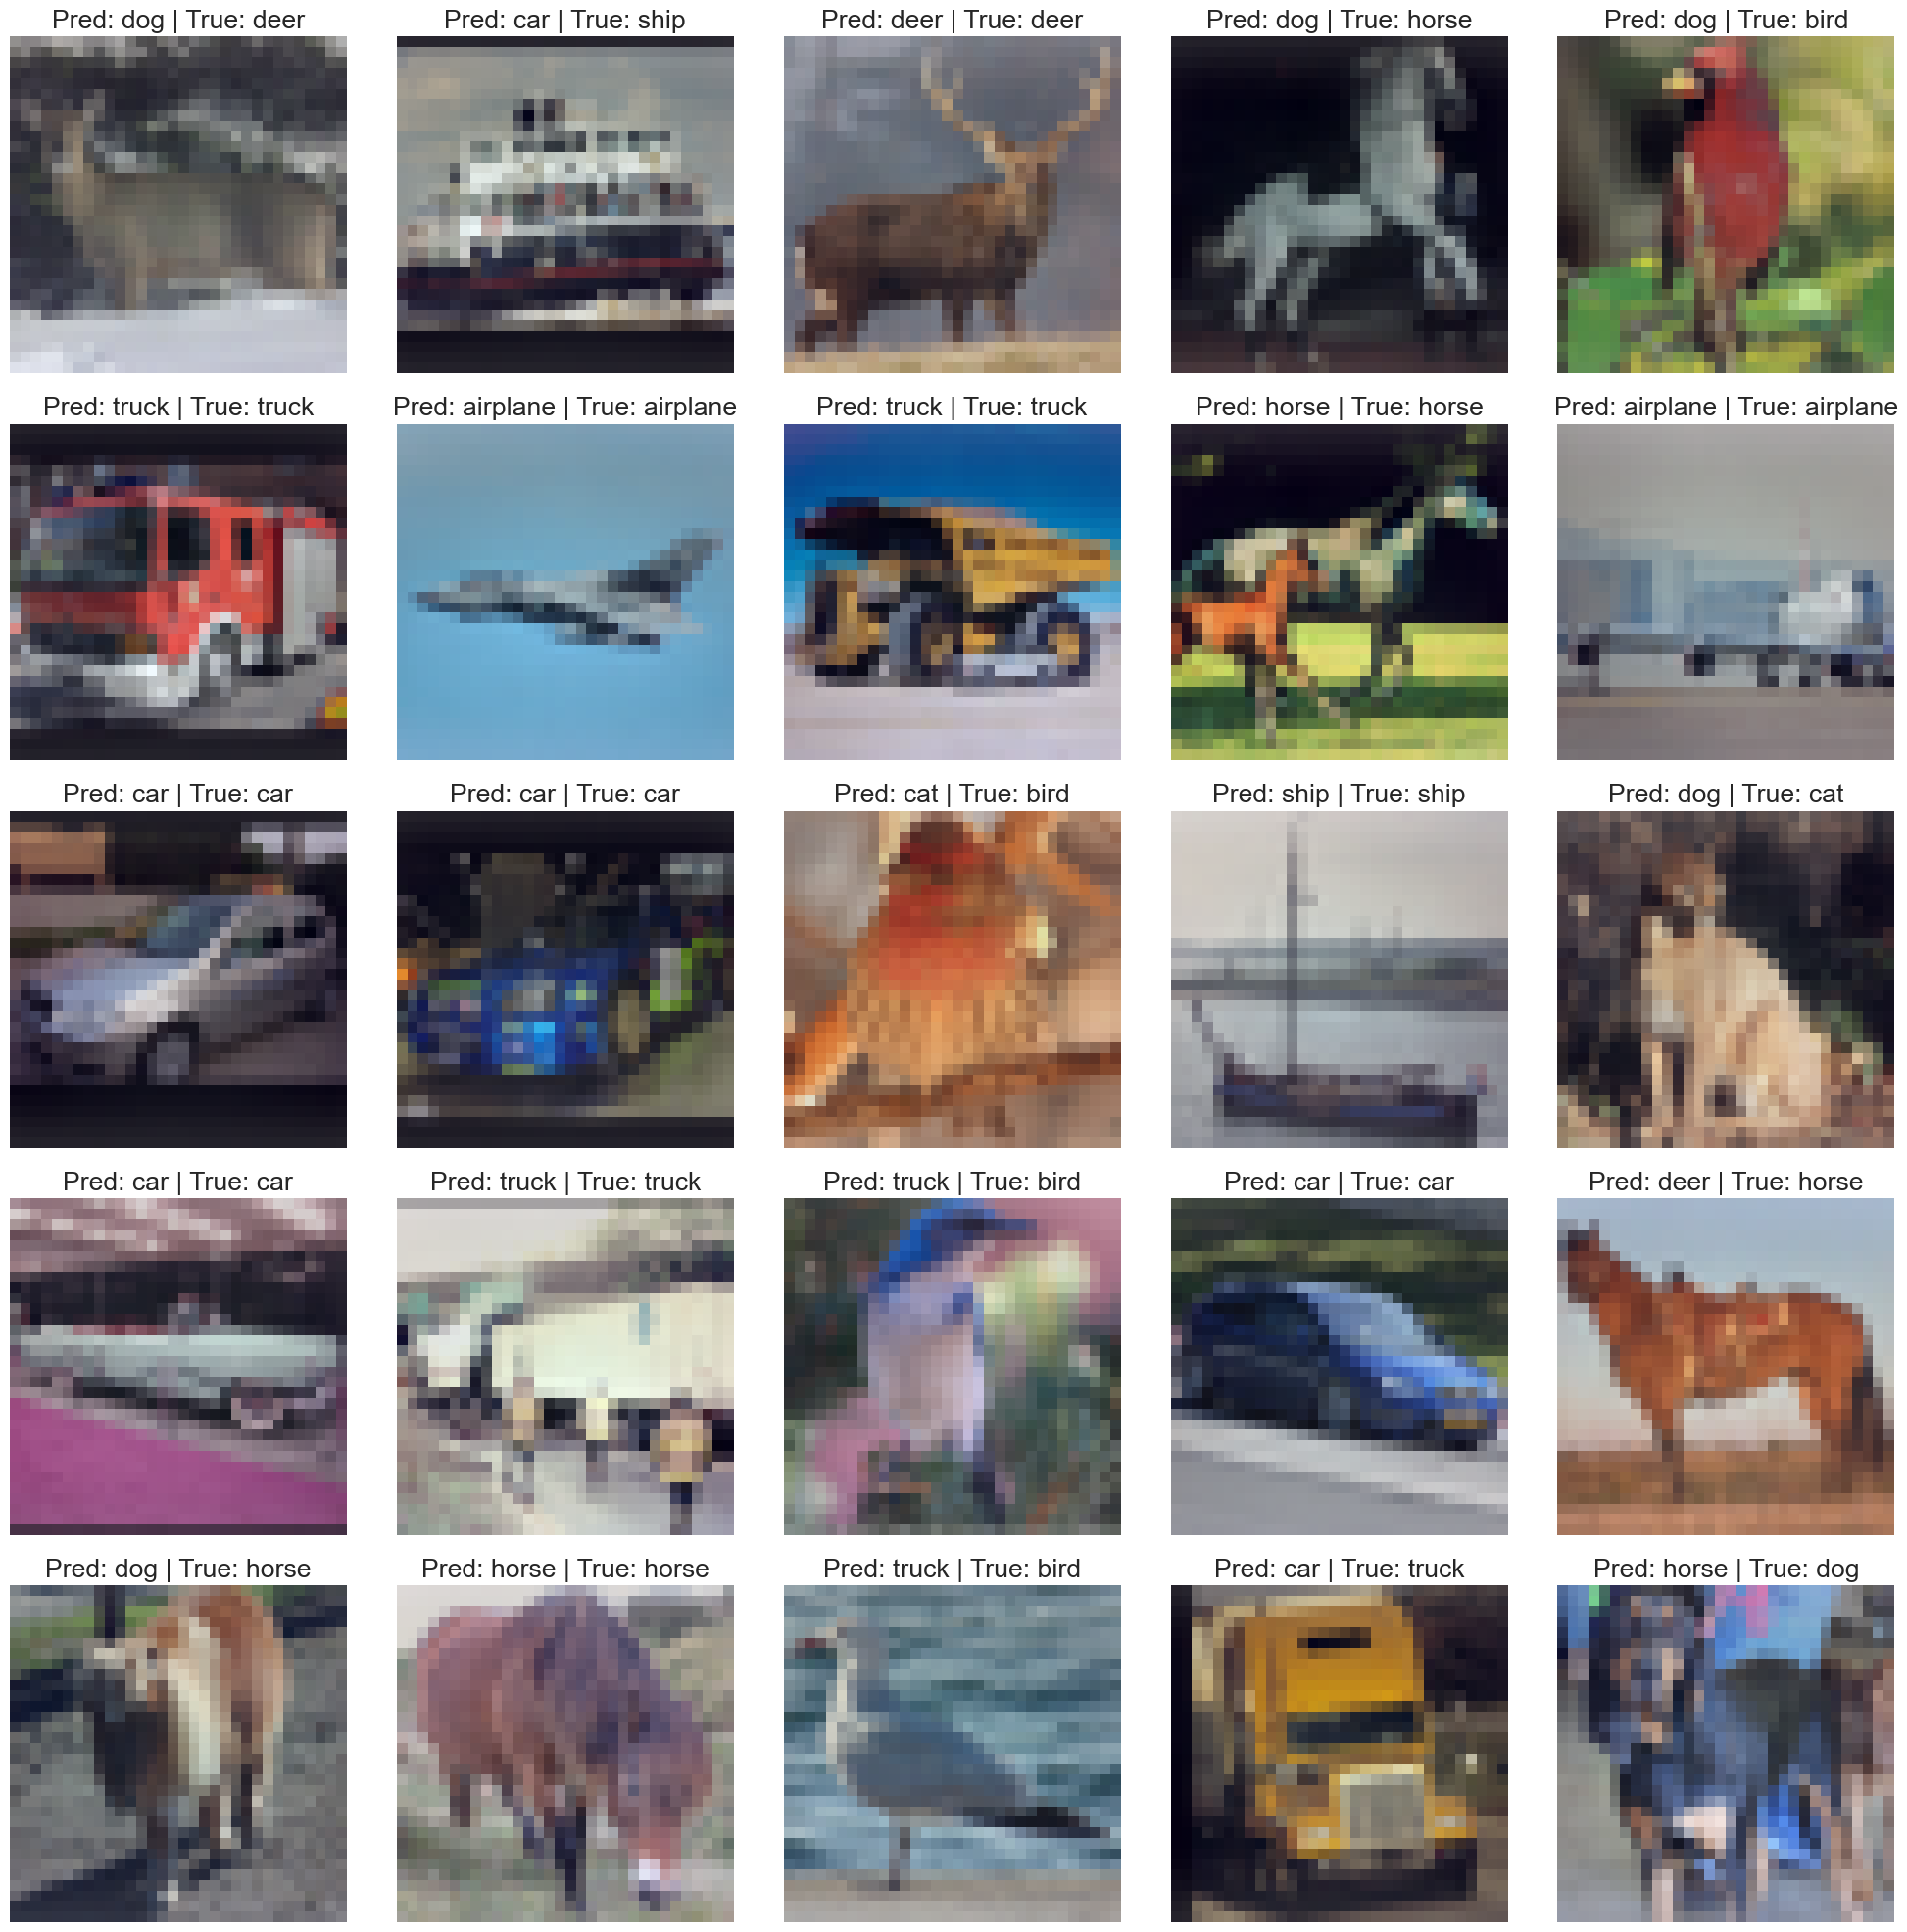

In [ ]:
test_img = tf.transpose(X_test[:25], [0, 2, 3, 1])
preds = model.predict(test_img)
test_img = test_img.numpy()
pred_labels = np.argmax(preds, axis=1)

#Avoid clippping to fit the range for RGB floats and ints 
min_val = tf.reduce_min(test_img)
max_val = tf.reduce_max(test_img)
test_img = (test_img - min_val) / (max_val - min_val) 
test_img = test_img.numpy()

fig, axes = plt.subplots(5, 5, figsize=(20, 20))
for idx, ax in enumerate(axes.flat):
    ax.imshow(test_img[idx])
    ax.set(xticks=[], yticks=[], title=f'Pred: {classes[pred_labels[idx]]} | True: {classes[y_test[idx]]}')

plt.tight_layout()
plt.show()


### 1d. Questions

**Question 1:** What accuracy do you get on the STL-10 test set? Briefly summarize any non-default hyperparameters that you used to obtain this result.

**Question 2:** How do the loss and accurary results compare to the CNN project?

**Question 3:** Identify a few misclassifications. Is there a discernable pattern?

**Answer 1:**

On the STL-10 dataset our highest accuracy was ~0.55. After discussing with a few classmates during training it seemed like the sweetspot for the test set was to adjust the dropout rate to be 0.1 and change the regularization term to be 0.01. These terms help with overfitting and make the model more robust by randomly removing neurons at the rate described above. 

**Answer 2:**

Our epochs are different so looking at the figures you'll need to keep the scale of the x_axis in mind, but the show a very similar picture. The results from this training implementation are similar to the CNN project, but its clear that this implementation has a higher val_acc and handles loss a bit better. Not to mention it didn't take nearly as long to train as the CNN project did.

**Answer 3:**

Dog, horse, and deer like to get mixed up a bit. Likely because of the general structure these animals have, when looking at edges and building up the image information it could be quite easy to think something with four legs and a fur coat that might be horse is really a deer. Another misclassification is truck and bird, I'm not really sure what pattern would explain this misclassification. 

## Task 2: Transfer learning

Here you will use TensorFlow to download the pre-trained MobileNetV2 network (you may also use another network like InceptionV3, VGG19, or EfficientNet, but MobileNetV2 likely will run noticeably faster on your machine). We will use transfer learning to accelerate training to solve a novel problem: **the binary classification task of discriminating whether an image is of a hotdog or not.**

### Overview

- Remove the output layer, add a new Dense output layer.
- Freeze (disable) training on all non-output layers.
- Train the last layer on a food dataset. Assess performance. Plot some example images and their classification below.

### 2a. Download and load in hotdot image dataset

Download the **food dataset** from the project website, copy it into a `data` subfolder in your project directory.

Run the below code to load in the hot-dog-or-not dataset. Check the shapes to ensure everything is loaded in correctly. 

In [81]:
ds_base_dir='data/'

hotdog_train_x = np.load(os.path.join(ds_base_dir, 'train_x.npy'))
hotdog_train_y = np.load(os.path.join(ds_base_dir, 'train_y.npy'))
hotdog_test_x = np.load(os.path.join(ds_base_dir, 'test_x.npy'))
hotdog_test_y = np.load(os.path.join(ds_base_dir, 'test_y.npy'))

print(f'Training hotdog split shape: {hotdog_train_x.shape}. Should be (16000, 96, 96, 3)')
print(f'Test hotdog split shape: {hotdog_test_x.shape}. Should be (4000, 96, 96, 3)')
print(hotdog_train_x.shape)

Training hotdog split shape: (16000, 96, 96, 3). Should be (16000, 96, 96, 3)
Test hotdog split shape: (4000, 96, 96, 3). Should be (4000, 96, 96, 3)
(16000, 96, 96, 3)


### 2b. Normalize hotdog dataset

Standardize both the train and test dataset according to the **same statistics** computed from the **training set**.

In [83]:
print(hotdog_train_x.shape)
mu = np.mean(hotdog_train_x, axis=(0, 1, 2))
sigma = np.std(hotdog_train_x, axis=(0, 1, 2))
hotdog_train_x = (hotdog_train_x - mu) / sigma
hotdog_test_x = (hotdog_test_x - mu) / sigma
print(hotdog_train_x.shape)

(16000, 96, 96, 3)
(16000, 96, 96, 3)


### 2c. Create hotdog validation set

Set aside the last 20% of the training set as the validation set

In [84]:
print(hotdog_train_x.shape)
split = int(0.8 * hotdog_train_x.shape[0])
hotdog_train_x, hotdog_val_x = hotdog_train_x[:split], hotdog_train_x[split:]
hotdog_train_y, hotdog_val_y = hotdog_train_y[:split], hotdog_train_y[split:]

(16000, 96, 96, 3)


In [85]:
print(f'Validation hotdog split shape: {hotdog_val_x.shape}. Should be (3200, 96, 96, 3)')
print(f'Training hotdog split shape: {hotdog_train_x.shape}. Should be (12800, 96, 96, 3)')

Validation hotdog split shape: (3200, 96, 96, 3). Should be (3200, 96, 96, 3)
Training hotdog split shape: (12800, 96, 96, 3). Should be (12800, 96, 96, 3)


### 2d. Load in pre-trained MobileNetV2 network.

Load in a pre-trained MobileNetV2 network (look up constructor in [tf.keras.applications](https://www.tensorflow.org/api_docs/python/tf/keras/applications/mobilenet_v2/MobileNetV2) or look at the tutorial from class) and set it to a variable called `model`. Remember to make the network not trainable. Calling the `summary()` method on the network object should show you a table with many rows. The top and bottom rows should be:

    Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
    ┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
    │ input_layer_19      │ (None, 96, 96, 3) │          0 │ -                 │
    │ (InputLayer)        │                   │            │            
                                        
    ├─────────────────────┼───────────────────┼────────────┼───────────────────┤
    │ out_relu (ReLU)     │ (None, 3, 3,      │          0 │ Conv_1_bn[0][0]   │
    │                     │ 1280)             │            │                   │  
                                                                                                  
==================================================================================================

and you should see the following at the bottom:

    Total params: 2,257,984 (8.61 MB)
    Trainable params: 0 (0.00 B)
    Non-trainable params: 2,257,984 (8.61 MB)

In [86]:
model = tf.keras.applications.MobileNetV2(weights='imagenet', include_top=False, input_shape=(96, 96, 3))
model.trainable = False
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenetv2_1.00_96"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

### 2e. Create augmented model

Create a new `keras::Sequential` augmented model with an output layer that has the correct number of units to deal with the hot-dog or not problem with your choice of optimizer, an appropriate loss, and metric(s).

#### Helpful links

https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dense

https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam

https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/AdamW

https://www.tensorflow.org/api_docs/python/tf/losses

In [92]:
tf.random.set_seed(0)
tf.keras.utils.set_random_seed(0)
np.random.seed(0)
tf.keras.backend.clear_session()

aug_model = tf.keras.Sequential([model, tf.keras.layers.Flatten(), tf.keras.layers.Dense(1, activation='sigmoid')])
aug_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
test_loss, test_acc = aug_model.evaluate(hotdog_test_x, hotdog_test_y)
print(f'Test accuracy: {test_acc:.2f}')
print(f'Test loss: {test_loss:.2f}')

125/125 ━━━━━━━━━━━━━━━━━━━━ 22s 155ms/step - accuracy: 0.5028 - loss: 0.9320
Test accuracy: 0.50
Test loss: 0.95


### 2f. Questions

**Question 4:** What is the accuracy and loss for the network with the untrained output layer on the test set? Explain why you got the accuracy value that you did.

**Question 5:** Briefly defend your choice of number of units in the output layer.

**Answer 4:**

The accuracy is 0.50 and the loss is 0.95. This makes sense because the model that hasn't been trained can only make random guesses as to which label the image should be classified to. This loss value shows confidence in the prediction. It's almost like the model is saying "hey, I am randomly assigning labels to the images and I know that they are not correct predictions but this is the best I can do".

**Answer 5:**

The classifcation is either hotdog or not hotdog and we use sigmoid as our activiation function. This means that z = [0, 1] corresponding to our labels. 1 output layer thefore makes the most sense because the data is getting labeled to 1 or 0. Not only do we care about the number of classes that our output layer may represent the activation function in those layers also determines how many layers we might need. A single output layer with sigmoid activation gives us two classes.

### 2g. Fit the augmented model on the hotdog training data

Setting the verbose optional parameter to 2 will give you helpful printouts of performance on the validation set as it completes every epoch of training.

#### Training goal

You should aim to achieve at least 85% accuracy on the validation set. If everything is set up properly, you should only need to train for a very small number of epochs.


#### Note

If training time is taking much more than a few minutes per epoch on your computer, you could try reducing the number of data samples in train and validation. For example, by default train `N = 12800`. Try `N = 6400` instead. You could do the same for the validation set.

In [93]:
history = aug_model.fit(hotdog_train_x, hotdog_train_y, epochs=3, validation_data=(hotdog_val_x, hotdog_val_y))

Epoch 1/3
400/400 ━━━━━━━━━━━━━━━━━━━━ 108s 255ms/step - accuracy: 0.7890 - loss: 0.5163 - val_accuracy: 0.8097 - val_loss: 0.5494
Epoch 2/3
400/400 ━━━━━━━━━━━━━━━━━━━━ 88s 219ms/step - accuracy: 0.8997 - loss: 0.2441 - val_accuracy: 0.8828 - val_loss: 0.3118
Epoch 3/3
400/400 ━━━━━━━━━━━━━━━━━━━━ 86s 215ms/step - accuracy: 0.9296 - loss: 0.1688 - val_accuracy: 0.8875 - val_loss: 0.3198


### 2h. Plot hotdog results

Produce 2 high quality plots showing the following:

- Training and validation loss over epoch.
- Training and validation accuracy over epoch.

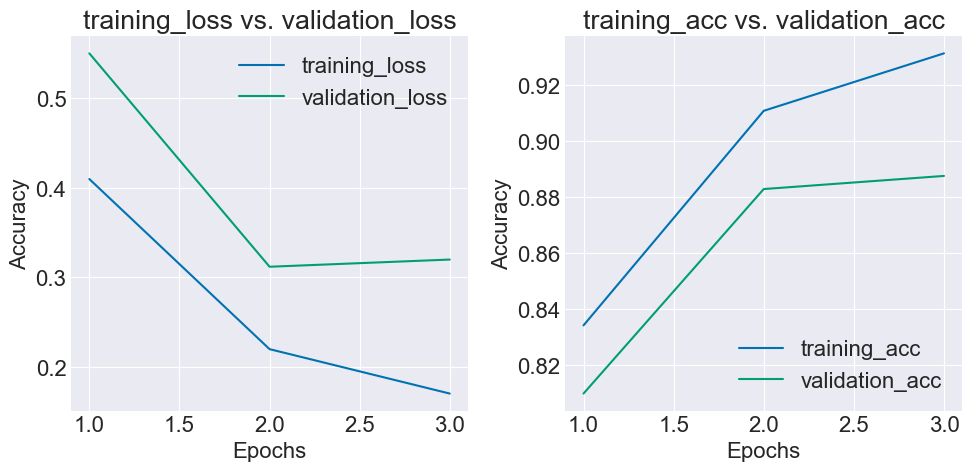

In [95]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epoch = range(1, len(acc)+ 1)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(epoch, loss, label='training_loss')
plt.plot(epoch, val_loss, label='validation_loss')
plt.title('training_loss vs. validation_loss')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epoch, acc, label='training_acc')
plt.plot(epoch, val_acc, label='validation_acc')
plt.title('training_acc vs. validation_acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

### 2i. Visualize predictions on test set

Use your trained hotdog classifier to get the predicted classes for the first 25 **test set** samples. Then create a 5x5 grid of the first 25 test samples and label each with the predicted class string (English label, not an int code).
- If the prediction is correct, color the label *blue*.
- If the prediction is incorrect, color the label *red*.

**Note:**
- Depending on how you get the network predictions, TensorFlow may give you a vector of class probabilities. This could be shape `(N, 2)` or `(N,)`, depending on the output layer activation function that you used. Remember that if you have these probabilities, you need to recover the predicted class index (e.g. `0`, `1`) before you can label your plots.
- If `imshow` gives you warnings about clipping, check the range of the test samples. If your max is slightly higher than 1, either ignore the warning or divide by the max. 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step


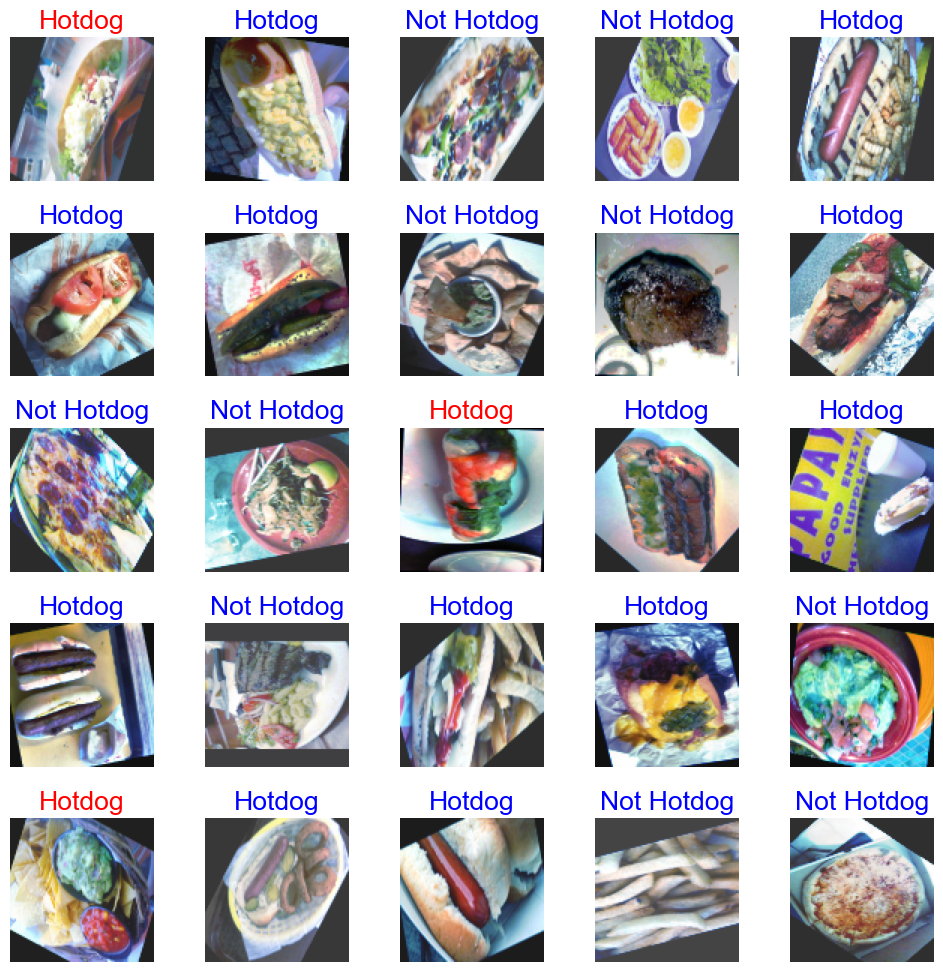

In [98]:
predictions = aug_model.predict(hotdog_test_x[:25])
predicted_classes = (predictions > 0.5).astype(int)

fig, axs = plt.subplots(5, 5, figsize=(10, 10))

test = hotdog_test_x[:25]
min_val = tf.reduce_min(test)
max_val = tf.reduce_max(test)
test_hotdog = (test - min_val) / (max_val - min_val)
hotdog = test_hotdog.numpy()

for idx, ax in enumerate(axs.flat):
    ax.imshow(hotdog[idx], cmap='grey')
    if predicted_classes[idx] == hotdog_test_y[idx]:
        ax.set_title(f'Hotdog' if predicted_classes[idx] < 0.5 else 'Not Hotdog', color='blue')
    else:
        ax.set_title(f'Hotdog' if predicted_classes[idx] < 0.5 else 'Not Hotdog', color='red')
    ax.axis('off')

plt.tight_layout()
plt.show()